Plotting data from measurements (NOVO51, NOVO139 and NOVO140)

In [102]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

folder_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Measurements"
tree_name = "image_tree"

runs = {"000051": [None, None], "000139": [None, None], "000140": [None, None]}
label_helper = {"000051": " : +0 mm", "000139": " : -167 mm", "000140": " : +183 mm"}
color_helper = {"000051": "tab:purple", "000139": "tab:pink", "000140": "mediumblue"}

In [103]:
for run in runs:

    file_PATH = folder_PATH + rf"\sorted_NOVO_{run}.root"

    with uproot.open(file_PATH) as file:
        tree = file[tree_name]

        arrays = tree.arrays(
            ["dE1", "particle1", "clipped1", "det1"],
            library="np"
        )

        for detector in [0, 1]:
            mask = (
            (arrays["particle1"] == 2) &
            (arrays["clipped1"] == 0) &
            (arrays["det1"] == detector) &
            (arrays["dE1"] >= 0) &
            (arrays["dE1"] <= 8)
            )

            dE1_selected = arrays["dE1"][mask]
            runs[run][detector] = dE1_selected


Number of bins: 160.0


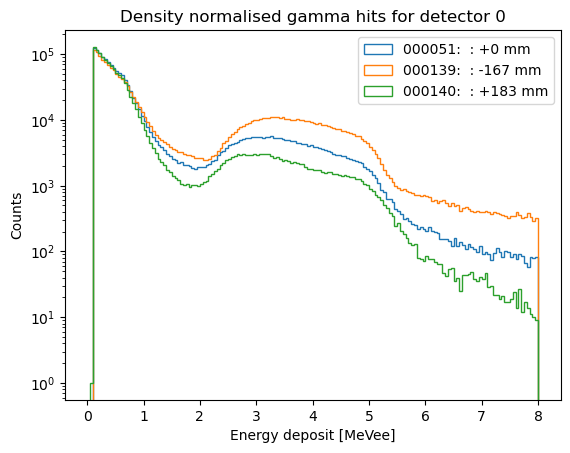

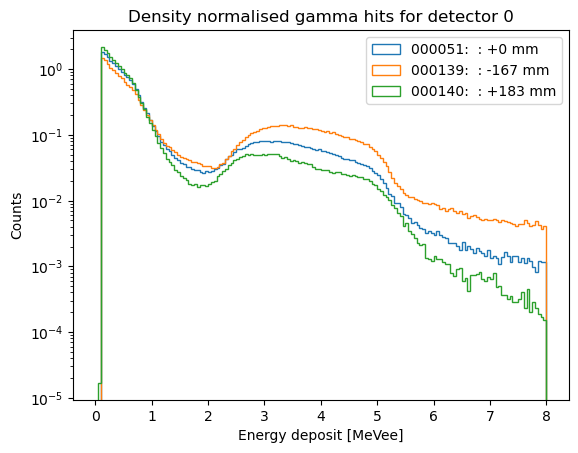

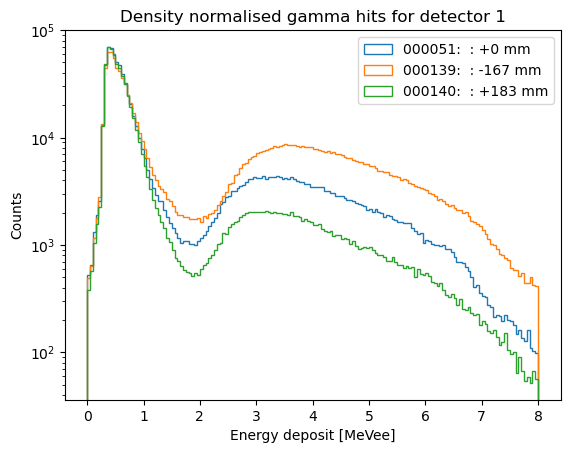

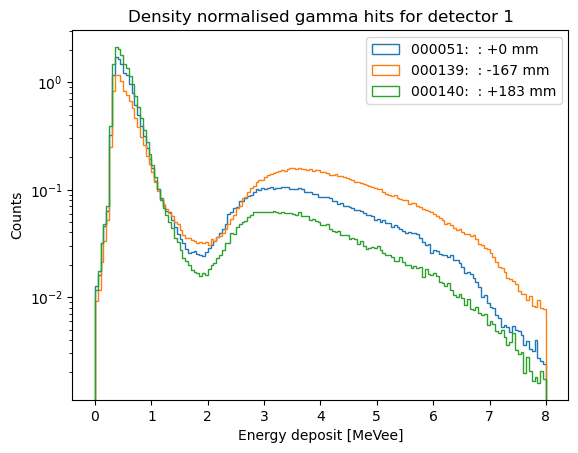

In [64]:
bin_width = 0.05 # MeV
max_energy = 8.0 # MeV
print(f"Number of bins: {max_energy/bin_width}")
bins = np.arange(0.0, max_energy + bin_width, bin_width)

for detector in [0, 1]:
    # Non-normalized plot
    plt.figure()

    for run_name, data in runs.items():
        plt.hist(data[detector], bins=bins, histtype="step", label=f"{run_name}: {label_helper[run_name]}", color=color_helper[run_name])

    plt.xlabel("Energy deposit [MeVee]")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.legend()
    plt.title(f"Density normalised gamma hits for detector {detector}")

    # Normalized plot
    plt.figure()

    for run_name, data in runs.items():
        plt.hist(data[detector], bins=bins, histtype="step", label=f"{run_name}: {label_helper[run_name]}", color=color_helper[run_name] , density=True)

    plt.xlabel("Energy deposit [MeVee]")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.legend()
    plt.title(f"Density normalised gamma hits for detector {detector}")



Plotting both dataset in the same plot

In [67]:
# Loading my data

from mgdraw_output_reader_NOVO_v03 import DetectionDataStorage
from mgdraw_txt_file_reader_06 import collect_txt_data

main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\2025-12_OncoRay_round2"

beam_current = 2 # nA
primaries_per_spawn = 1.5e7
number_of_files = 70

files = {"NOVO51": None, "NOVO139": None, "NOVO140": None}

for run in files:
    PATH = main_PATH + rf"\{run}\scintillator_interactions"

    files[run] = DetectionDataStorage(PATH, primaries_per_spawn=primaries_per_spawn, max_files=number_of_files)
    files[run].load_data(mgdraw_version_8_plus=True)
    files[run].filter_hits(beam_current=beam_current, write_hits_to_file=False)
    files[run].event_builder(write_ngimager_file=False)

Reading 70 scintillator_interactions.txt-files
Line:  6083730 300  8  8  0  1 -2    0.000000   0.000000   73.23001  -2.79292  16.76584     9   35 ***********   3.827359   6.436274   7.202403   0.000821

*********** found in file <_io.TextIOWrapper name='C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO51/scintillator_interactions/OncoRay51_model_spawn_17001_scintillator_interactions.txt' mode='r' encoding='utf-8'>
Line:  6083730 300  8  8  0  1 -2    0.000000   0.000000   73.17122  -2.20173  16.42816     9   37 ***********   3.827359   6.436274   7.202403   0.000821

*********** found in file <_io.TextIOWrapper name='C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO51/scintillator_interactions/OncoRay51_model_spawn_17001_scintillator_interactions.txt' mode='r' encoding='utf-8'>
Line:  6083730 300  8  8  0  1 -2    0.000000   0.000000   73.67462  -2.34834  16.38493     9   38 

Number of bins: 160.0


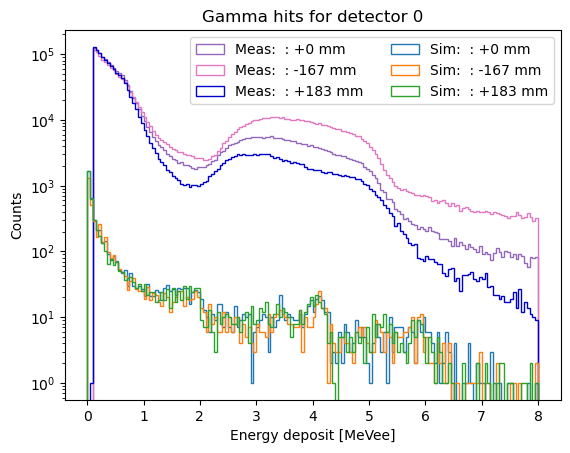

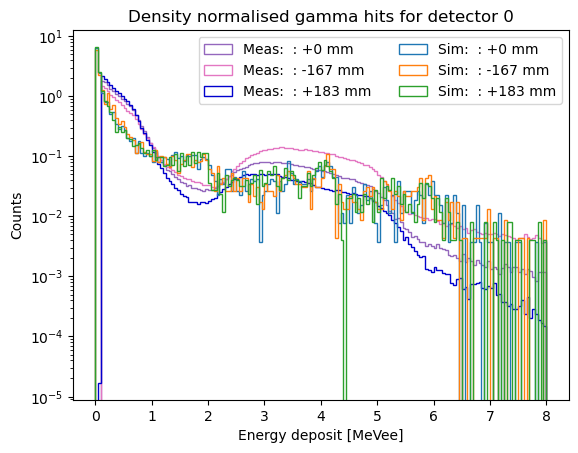

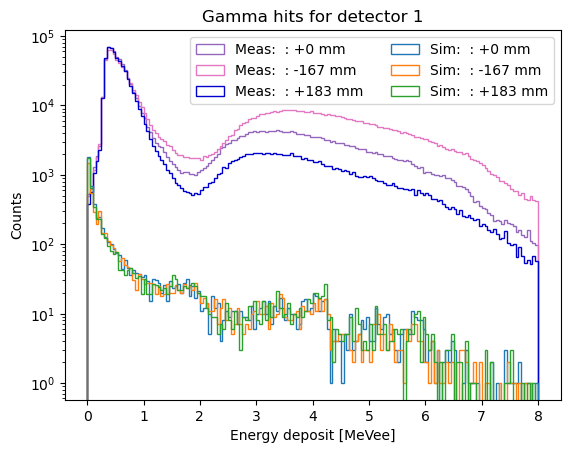

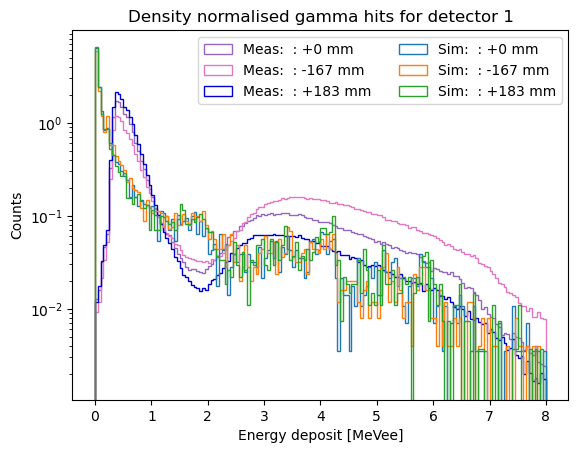

In [108]:
bin_width = 0.05 # MeV
max_energy = 8.0 # MeV
print(f"Number of bins: {max_energy/bin_width}")
bins = np.arange(0.0, max_energy + bin_width, bin_width)

label_helper = {"000051": " : +0 mm", "000139": " : -167 mm", "000140": " : +183 mm"}
color_helper = {"000051": "tab:purple", "000139": "tab:pink", "000140": "mediumblue"}

label_helper2 = {"NOVO51": " : +0 mm", "NOVO139": " : -167 mm", "NOVO140": " : +183 mm"}
color_helper2 = {"NOVO51": "tab:blue", "NOVO139": "tab:orange", "NOVO140": "tab:green"}

for detector in [0, 1]:
    # Non-normalized plot
    plt.figure()

    # Measurement data
    for run_name, data in runs.items():
        plt.hist(data[detector], bins=bins, histtype="step", label=f"Meas: {label_helper[run_name]}", color=color_helper[run_name], linestyle="-")

    # Simulation data
    for run_name, data in files.items():

        gamma_hits = data.gamma_hits[:, 7]   # Energy depositions
        gamma_regions = data.gamma_hits[:, 12]   # Regions
        gamma_region_mask = gamma_regions==(detector+1)
        gamma_region_hits = gamma_hits[gamma_region_mask]

        plt.hist(gamma_region_hits, bins=bins, histtype="step", label=f"Sim: {label_helper2[run_name]}", color=color_helper2[run_name], linestyle="-")

    plt.xlabel("Energy deposit [MeVee]")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.legend(ncol=2)
    plt.title(f"Gamma hits for detector {detector}")



    # Normalized plot
    plt.figure()

    # Measurement data
    for run_name, data in runs.items():
        plt.hist(data[detector], bins=bins, histtype="step", label=f"Meas: {label_helper[run_name]}", color=color_helper[run_name], linestyle="-", density=True)

    # Simulation data
    for run_name, data in files.items():

        gamma_hits = data.gamma_hits[:, 7]   # Energy depositions
        gamma_regions = data.gamma_hits[:, 12]   # Regions
        gamma_region_mask = gamma_regions==(detector+1)
        gamma_region_hits = gamma_hits[gamma_region_mask]

        plt.hist(gamma_region_hits, bins=bins, histtype="step", label=f"Sim: {label_helper2[run_name]}", color=color_helper2[run_name], linestyle="-", density=True)

    plt.xlabel("Energy deposit [MeVee]")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.legend(ncol=2)
    plt.title(f"Density normalised gamma hits for detector {detector}")